# **Módulo B -> Projeto ECAC 2025 — Classificação de Atividades Humanas**


In [1]:
#!pip install skrebate
#!pip install scikit_posthocs
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skrebate import ReliefF  
from collections import Counter
from scipy.fft import rfft, rfftfreq
from scipy import stats
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
import time
from sklearn.neighbors import KNeighborsClassifier
import torch
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

### carregar atividades de 1 a 7

In [2]:
def load_participant(part_id, dataset_folder):
    folder = os.path.join(dataset_folder, f'part{part_id}')
    if not os.path.isdir(folder):
        raise FileNotFoundError(f'Pasta {folder} não encontrada.')
    dfs = []
    for dev in range(1, 6):
        path = os.path.join(folder, f'part{part_id}dev{dev}.csv')
        if not os.path.isfile(path):
            print('Aviso: ficheiro não encontrado:', path)
            continue
        cols = ['device_id','acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z',
                'mag_x','mag_y','mag_z','timestamp','activity']
        df = pd.read_csv(path, header=None, names=cols)
        df['participant'] = int(part_id) 
        dfs.append(df)
    if not dfs:
        return pd.DataFrame(columns=cols + ['participant'])
    return pd.concat(dfs, ignore_index=True)

def load_all(dataset_folder, participants=range(0,15)):
    all_dfs = []
    for p in participants:
        try:
            dfp = load_participant(p, dataset_folder=dataset_folder)
            if not dfp.empty:
                dfp = dfp[dfp['activity'].between(1, 7)]
                all_dfs.append(dfp)
        except FileNotFoundError as e:
            print(e)

    if not all_dfs:
        return pd.DataFrame()
    return pd.concat(all_dfs, ignore_index=True)


df = load_all('FORTH_TRACE_DATASET-master', participants=range(0,15))
print(df.shape)

(3718503, 13)


## features (4.2. da meta 1)

In [3]:
def compute_sampling_rate(timestamps):
    t = np.array(timestamps, dtype=float)
    if np.median(t) > 1e3:
        t = t / 1000.0
    diffs = np.diff(t)
    diffs = diffs[diffs > 1e-6]
    if len(diffs) == 0:
        return 1.0, t
    median_dt = np.median(diffs)
    fs = 1.0 / median_dt
    return fs, t

def sliding_windows(df, window_seconds=5.0, overlap=0.5, time_col='timestamp'):
    fs, t = compute_sampling_rate(df[time_col].values)
    step = window_seconds * (1 - overlap)
    start_time = t[0]
    end_time = t[-1]
    starts = np.arange(start_time, end_time - window_seconds + 1e-9, step)
    for s in starts:
        e = s + window_seconds
        mask = (t >= s) & (t < e)
        idxs = np.where(mask)[0]
        if len(idxs) < 2:
            continue
        yield idxs[0], idxs[-1] + 1, df.iloc[idxs].copy(), s, fs

# ESTATÍSTICAS TEMPORAIS
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def avg_derivative(x, dt):
    if len(x) < 2:
        return 0.0
    dx = np.diff(x) / dt
    return np.mean(dx)

def zero_crossing_rate(x):
    s = np.sign(x)
    s[s == 0] = 1
    zc = np.sum(s[:-1] * s[1:] < 0)
    return zc / max(1, len(x))

def mean_crossing_rate(x):
    mu = np.mean(x)
    s = np.sign(x - mu)
    s[s == 0] = 1
    mcr = np.sum(s[:-1] * s[1:] < 0)
    return mcr / max(1, len(x))

def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

def pairwise_correlations(window_axes):
    x = window_axes['x']; y = window_axes['y']; z = window_axes['z']
    def safe_corr(a, b):
        if np.std(a) == 0 or np.std(b) == 0:
            return 0.0
        return np.corrcoef(a, b)[0,1]
    return {
        'corr_xy': safe_corr(x, y),
        'corr_xz': safe_corr(x, z),
        'corr_yz': safe_corr(y, z)
    }

def spectral_entropy(x, fs, nfft=None):
    if nfft is None:
        nfft = max(256, 2**(int(np.ceil(np.log2(len(x))))))
    X = np.abs(rfft(x, n=nfft))**2
    X = X[1:]
    ssum = np.sum(X) + 1e-12
    psd = X / ssum
    se = -np.sum(psd * np.log2(psd + 1e-12))
    return se

def dominant_frequency(x, fs, nfft=None):
    if nfft is None:
        nfft = max(256, 2**(int(np.ceil(np.log2(len(x))))))
    X = np.abs(rfft(x, n=nfft))**2
    freqs = rfftfreq(nfft, 1.0/fs)
    X = X.copy()
    if len(X) > 0:
        X[0] = 0.0
    if np.all(X == 0):
        return 0.0, 0.0
    idx = np.argmax(X)
    return freqs[idx], X[idx]

def energy_freq_domain(x, fs, nfft=None):
    if nfft is None:
        nfft = max(256, 2**(int(np.ceil(np.log2(len(x))))))
    X = np.abs(rfft(x, n=nfft))**2
    if len(X) > 0:
        X[0] = 0.0
    return np.sum(X) / max(1.0, len(x))

def averaged_acceleration_energy(ax, ay, az, fs):
    e_x = energy_freq_domain(ax, fs)
    e_y = energy_freq_domain(ay, fs)
    e_z = energy_freq_domain(az, fs)
    return np.mean([e_x, e_y, e_z])

def averaged_rotation_energy(gx, gy, gz, fs):
    e_x = energy_freq_domain(gx, fs)
    e_y = energy_freq_domain(gy, fs)
    e_z = energy_freq_domain(gz, fs)
    return np.mean([e_x, e_y, e_z])

# Função principal de extração de features
def extract_features_window(df_window, fs, axes_map):
    feats = {}
    def get_col(arr, name):
        if name in df_window.columns:
            return df_window[name].to_numpy(dtype=float)
        return np.zeros(len(df_window), dtype=float)

    ax = get_col(df_window, axes_map['acc'][0])
    ay = get_col(df_window, axes_map['acc'][1])
    az = get_col(df_window, axes_map['acc'][2])
    gx = get_col(df_window, axes_map['gyro'][0])
    gy = get_col(df_window, axes_map['gyro'][1])
    gz = get_col(df_window, axes_map['gyro'][2])
    mx = get_col(df_window, axes_map['mag'][0])
    my = get_col(df_window, axes_map['mag'][1])
    mz = get_col(df_window, axes_map['mag'][2])

    dt = 1.0 / fs if fs > 0 else 0.01

    channels = {
        'acc_x':ax, 'acc_y':ay, 'acc_z':az,
        'gyro_x':gx, 'gyro_y':gy, 'gyro_z':gz,
        'mag_x':mx, 'mag_y':my, 'mag_z':mz
    }
    for name, x in channels.items():
        if x.size == 0:
            vals = dict(
                mean=0, median=0, std=0, var=0, rms=0,
                avg_derivative=0, skew=0, kurtosis=0, iqr=0,
                zc_rate=0, mc_rate=0, spec_entropy=0, dominant_freq=0, energy=0
            )
        else:
            vals = dict(
                mean=np.mean(x),
                median=np.median(x),
                std=np.std(x, ddof=0),
                var=np.var(x, ddof=0),
                rms=rms(x),
                avg_derivative=avg_derivative(x, dt),
                skew=stats.skew(x),
                kurtosis=stats.kurtosis(x),
                iqr=iqr(x),
                zc_rate=zero_crossing_rate(x),
                mc_rate=mean_crossing_rate(x),
                spec_entropy=spectral_entropy(x, fs),
                dominant_freq=dominant_frequency(x, fs)[0],
                energy=energy_freq_domain(x, fs)
            )
        feats.update({f'{name}_{k}': v for k,v in vals.items()})

    feats.update({f'acc_{k}':v for k,v in pairwise_correlations({'x':ax,'y':ay,'z':az}).items()})
    feats.update({f'gyro_{k}':v for k,v in pairwise_correlations({'x':gx,'y':gy,'z':gz}).items()})
    feats.update({f'mag_{k}':v for k,v in pairwise_correlations({'x':mx,'y':my,'z':mz}).items()})
    feats['AAE'] = averaged_acceleration_energy(ax,ay,az,fs)
    feats['ARE'] = averaged_rotation_energy(gx,gy,gz,fs)

    return feats

# Função para extrair features de todo o DataFrame
def extract_features_file(df, window_seconds=5.0, overlap=0.5,
                          time_col='timestamp', activity_col='activity',
                          participant_col='participant', device_col='device_id',
                          axes_map=None):
    if axes_map is None:
        axes_map = {'acc':['acc_x','acc_y','acc_z'],
                    'gyro':['gyro_x','gyro_y','gyro_z'],
                    'mag':['mag_x','mag_y','mag_z']}

    rows = []
    participants = df[participant_col].unique() if participant_col in df.columns else [None]
    for part in participants:
        df_part = df[df[participant_col] == part] if part is not None else df
        devices = df_part[device_col].unique() if device_col in df_part.columns else [None]
        for dev in devices:
            df_dev = df_part[df_part[device_col] == dev] if dev is not None else df_part
            for i0, i1, wdf, start_time, fs in sliding_windows(
                df_dev, window_seconds=window_seconds, overlap=overlap, time_col=time_col
            ):
                labels = wdf[activity_col].unique() if activity_col in wdf.columns else np.array(['unknown'])
                if len(labels) != 1:
                    continue
                label = labels[0]
                feats = extract_features_window(wdf, fs, axes_map=axes_map)
                feats['window_start'] = start_time
                feats['window_end'] = start_time + window_seconds
                feats['activity'] = label
                feats['participant'] = part
                feats['device_id'] = dev
                rows.append(feats)
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.DataFrame(rows)

In [4]:
features = extract_features_file(df, window_seconds=5.0, overlap=0.5)
print(features.shape)

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_25444\2239223687.py:148: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew=stats.skew(x),
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_25444\2239223687.py:149: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis=stats.kurtosis(x),


(29776, 142)


In [5]:
metadata_cols = ['window_start', 'window_end', 'activity', 'participant', 'device_id']
features_cols = [c for c in features.columns if c not in metadata_cols]

# Remoção de NaNs
valid_idx = ~features[features_cols].isna().any(axis=1)
features = features[valid_idx].reset_index(drop=True)

In [6]:
features.head()

,acc_x_mean,acc_x_median,acc_x_std,acc_x_var,acc_x_rms,acc_x_avg_derivative,acc_x_skew,acc_x_kurtosis,acc_x_iqr,acc_x_zc_rate,...,mag_corr_xy,mag_corr_xz,mag_corr_yz,AAE,ARE,window_start,window_end,activity,participant,device_id
0,-1.718786,-1.71330,0.088848,0.007894,1.721080,0.022706,-0.286346,0.192488,0.104025,0.0,...,0.586695,-0.065357,-0.143222,1.522192,363.786515,0.50589,5.50589,1,0,1
1,-1.677683,-1.70150,0.172424,0.029730,1.686520,0.078471,0.812407,7.354062,0.134250,0.0,...,0.479890,0.151324,0.048799,2.243157,1315.294249,3.00589,8.00589,1,0,1
2,-1.588744,-1.57750,0.172266,0.029676,1.598056,0.017098,-0.337707,6.778242,0.178350,0.0,...,0.364287,0.438884,0.342720,1.723560,1212.083343,5.50589,10.50589,1,0,1
3,-1.557541,-1.56515,0.063835,0.004075,1.558849,-0.023196,0.253481,-0.362451,0.084300,0.0,...,-0.104231,0.449060,-0.411119,1.806601,292.705741,8.00589,13.00589,1,0,1
4,-1.644344,-1.61375,0.167250,0.027973,1.652828,-0.122863,-0.529080,4.854240,0.106025,0.0,...,-0.056424,0.622469,-0.439985,3.746262,907.713905,10.50589,15.50589,1,0,1


# 1. Data Augmentation

## 1.1.

Distribuição por atividade:
activity
1    6453
2    3438
3    3427
4    5548
5    5587
6    3547
7    1773
Name: count, dtype: int64


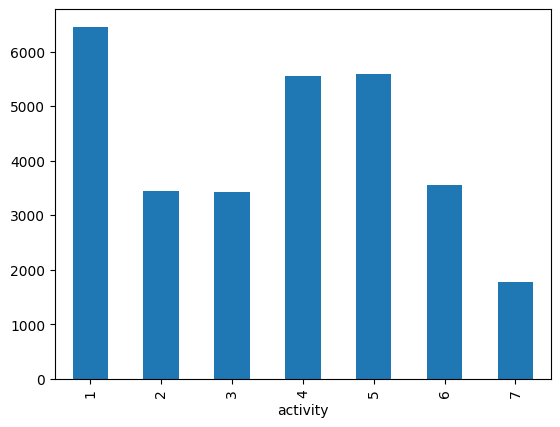

In [6]:
def analyze_balance(df):
    print("Distribuição por atividade:")
    print(df['activity'].value_counts().sort_index())

    df['activity'].value_counts().sort_index().plot(kind='bar')
analyze_balance(features)

## 1.2. 

In [7]:
def smote_generate(X, y, activity, K=5, n_new=3):
    Xa = X[y == activity]
    if Xa.shape[0] < K:
        raise ValueError("Atividade tem menos que K amostras, SMOTE não é possível.")
    knn = NearestNeighbors(n_neighbors=K+1).fit(Xa)
    neighbors = knn.kneighbors(Xa, return_distance=False)[:, 1:]  
    synthetic = []
    for _ in range(n_new):
        idx = np.random.randint(0, Xa.shape[0])
        x_i = Xa[idx]

        # escolher um vizinho aleatório
        nn = neighbors[idx, np.random.randint(0, K)]
        x_nn = Xa[nn]

        # interpolação
        lam = np.random.rand()
        x_new = x_i + lam * (x_nn - x_i)
        synthetic.append(x_new)
    return np.array(synthetic)


## 1.3. 

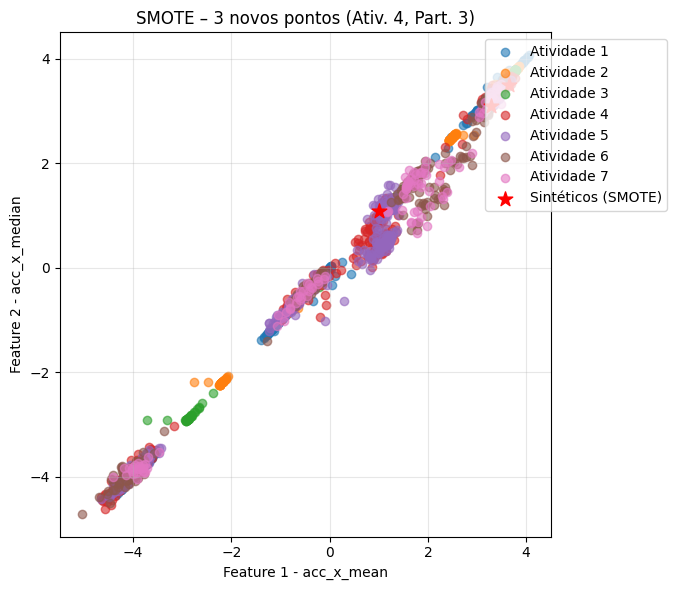

In [8]:
features_smote = features.copy()
def generate_and_plot_participant(df, participant_id, activity_id):
    df_p = df[df['participant'] == participant_id]
    Xp = df_p[features_cols].values
    yp = df_p['activity'].values

    # gerar 3 exemplos sintéticos
    syn = smote_generate(Xp, yp, activity=activity_id, K=5, n_new=3)

    plt.figure(figsize=(7,6))

    # pontos reais
    for act in sorted(df_p['activity'].unique()):
        mask = (yp == act)
        plt.scatter(Xp[mask, 0], Xp[mask, 1], label=f"Atividade {act}", alpha=0.6)

    # pontos sintéticos
    plt.scatter(syn[:,0], syn[:,1], c='red', s=120, marker='*', 
                label='Sintéticos (SMOTE)')
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.title(f"SMOTE – 3 novos pontos (Ativ. {activity_id}, Part. {participant_id})")
    plt.xlabel(f"Feature 1 - {features_cols[0]}")
    plt.ylabel(f"Feature 2 - {features_cols[1]}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return syn
syn_samples = generate_and_plot_participant(features_smote, participant_id=3, activity_id=4)

# 2. Embedding features

## 2.1.

In [ ]:
def load_model():
    repo = 'OxWearables/ssl-wearables'
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    model.eval()
    
    feature_encoder = model.feature_extractor
    feature_encoder.to("cpu")
    feature_encoder.eval()
    
    return feature_encoder

# RESAMPLE para 30 Hz durante 5s → 150 samples

def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    fs_target = 30.0
    win_size = 5  # seconds

    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0 / fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)

    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target

# SEGMENTAÇÃO POR AMOSTRAS
def segment_by_samples(data, fs=51.5, win_sec=5, overlap=0.5):
    win_samples = int(win_sec * fs)      # ~258
    step = int(win_samples * (1 - overlap))  # 50% overlap

    acc = data[:, 1:4]
    acts = data[:, -2]

    segments, activities = [], []

    for start in range(0, len(acc) - win_samples, step):
        end = start + win_samples
        seg = acc[start:end]
        act = acts[start:end]

        # Mantém apenas segmentos com atividade consistente
        if np.all(act == act[0]):
            segments.append(seg)
            activities.append(act[0])

    return segments, activities

# LOAD PARTICIPANTS
def load_participant(part_id, dataset_folder):
    folder = os.path.join(dataset_folder, f'part{part_id}')
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Pasta {folder} não encontrada.")

    dfs = []
    for dev in range(1, 6):
        path = os.path.join(folder, f'part{part_id}dev{dev}.csv')
        if not os.path.isfile(path):
            print("Aviso: ficheiro não encontrado:", path)
            continue
        
        cols = ['device_id','acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z',
                'mag_x','mag_y','mag_z','timestamp','activity']
        
        df = pd.read_csv(path, header=None, names=cols)
        df['participant'] = int(part_id)
        dfs.append(df)

    if not dfs:
        return pd.DataFrame(columns=cols + ['participant'])
    
    return pd.concat(dfs, ignore_index=True)

def load_all(dataset_folder, participants=range(0,15)):
    all_dfs = []
    for p in participants:
        try:
            dfp = load_participant(p, dataset_folder)
            if not dfp.empty:
                dfp = dfp[dfp['activity'].between(1, 7)]
                all_dfs.append(dfp)
        except FileNotFoundError as e:
            print(e)

    if not all_dfs:
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)

# PROCESSAMENTO COMPLETO

dataset_path = "FORTH_TRACE_DATASET-master"
df = load_all(dataset_path, participants=range(0,15))
print("Dataset carregado:", df.shape)

feature_encoder = load_model()

final_embeddings = []
final_activities = []
final_participants = []
final_devices = []

# Processa participante × device
for (participant, device), df_sub in df.groupby(["participant", "device_id"]):
    
    print(f"Processando part {participant}, device {device} ...")

    data_np = df_sub.to_numpy()

    # SEGMENT OS DADOS
    segments, activities = segment_by_samples(data_np)

    # RESAMPLE
    resampled_segments = []
    valid_activities = []

    for seg, act in zip(segments, activities):
        res, _ = resample_to_30hz_5s(seg, 51.5)
        if res.shape == (150, 3):
            resampled_segments.append(res)
            valid_activities.append(act)

    if len(resampled_segments) == 0:
        print("⚠ Nenhum segmento válido aqui.")
        continue

    # CONVERTE PARA MODELO
    x_all = np.transpose(np.array(resampled_segments), (0, 2, 1))  # (N, 3, 150)

    # EMBEDDINGS
    batch_size = 64
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
            eb = feature_encoder(xb)
            final_embeddings.append(eb.cpu().numpy())

    # Guarda metadata
    final_activities.extend(valid_activities)
    final_participants.extend([participant] * len(valid_activities))
    final_devices.extend([device] * len(valid_activities))

# FINALIZA

# Concatena embeddings
embeddings = np.concatenate(final_embeddings, axis=0)  # shape (N, 512, 1)

# Remove a última dimensão extra
embeddings = embeddings.reshape(embeddings.shape[0], -1)  # shape (N, 512)

print("Shape final embeddings 2D:", embeddings.shape)


df_emb = pd.DataFrame(embeddings)
df_emb["activity"] = final_activities
df_emb["participant"] = final_participants
df_emb["device_id"] = final_devices

print("DF final:", df_emb.shape)


Dataset carregado: (3718503, 13)


Using cache found in C:\Users\Utilizador/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
Processando part 0, device 1 ...
Processando part 0, device 2 ...
Processando part 0, device 3 ...
Processando part 0, device 4 ...
Processando part 0, device 5 ...
Processando part 1, device 1 ...
Processando part 1, device 2 ...
Processando part 1, device 3 ...
Processando part 1, device 4 ...
Processando part 1, device 5 ...
Processando part 2, device 1 ...
Processando part 2, device 2 ...
Processando part 2, device 3 ...
Processando part 2, device 4 ...
Processando part 2, device 5 ...
Processando part 3, device 1 ...
Processando part 3, device 2 ...
Processando part 3, device 3 ...
Processando part 3, device 4 ...
Processando part 3, device 5 ...
Processando part 4, device 1 ...
Processando part 4, device 2 ...
Processando part 4, device 3 ...
Processando part 4, device 4 ...
Processando part 4, device 5 ...
Processando part 5, device 1 ...
Processando part 5, device 2 ...
Processando part 5, device 3 ...
Processando part 5, device 4 ...
Processando part 5, devi

In [11]:
df_emb.head()

,0,1,2,3,4,5,6,7,8,9,...,505,506,507,508,509,510,511,activity,participant,device_id
0,0.0,0.0,0.0,0.0,0.027918,0.050544,0.0,0.045986,0.0,0.042598,...,0.0,0.0,0.009035,0.087423,0.039968,0.000000,0.004214,1.0,0,1
1,0.0,0.0,0.0,0.0,0.024118,0.048658,0.0,0.050324,0.0,0.039458,...,0.0,0.0,0.009391,0.087132,0.039028,0.000000,0.004464,1.0,0,1
2,0.0,0.0,0.0,0.0,0.026060,0.054277,0.0,0.050402,0.0,0.041543,...,0.0,0.0,0.010609,0.083031,0.041698,0.000000,0.003229,1.0,0,1
3,0.0,0.0,0.0,0.0,0.027509,0.050486,0.0,0.042780,0.0,0.043780,...,0.0,0.0,0.008737,0.086540,0.037699,0.000000,0.002606,1.0,0,1
4,0.0,0.0,0.0,0.0,0.025639,0.045604,0.0,0.048992,0.0,0.039898,...,0.0,0.0,0.011520,0.089459,0.040962,0.001253,0.005678,1.0,0,1


In [12]:
print("Verificação do DataFrame df_emb:")
print(df_emb[['participant', 'activity']].head(10))
print("Valores únicos em 'activity':", df_emb['activity'].unique())
print("Valores únicos em 'participant':", df_emb['participant'].unique())

Verificação do DataFrame df_emb:
   participant  activity
0            0       1.0
1            0       1.0
2            0       1.0
3            0       1.0
4            0       1.0
5            0       1.0
6            0       1.0
7            0       1.0
8            0       1.0
9            0       1.0
Valores únicos em 'activity': [1. 2. 3. 4. 5. 6. 7.]
Valores únicos em 'participant': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


# 3. Data splitting strategy

In [13]:
IGNORE_COLS = ['window_start', 'window_end', 'activity', 'participant', 'device_id']

## 3.1. Split 1 - Within Subject

In [14]:
def split_1(df, features_cols):
    X_train_list, X_val_list, X_test_list = [], [], []
    y_train_list, y_val_list, y_test_list = [], [], []

    for participant, df_sub in df.groupby("participant"):
        X = df_sub[features_cols].values
        y = df_sub["activity"].values

        # split train 60% vs temp 40%
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.4, stratify=y, random_state=42
        )
        # split temp 50-50 -> val/test 20% each
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
        )

        X_train_list.append(X_train)
        X_val_list.append(X_val)
        X_test_list.append(X_test)
        y_train_list.append(y_train)
        y_val_list.append(y_val)
        y_test_list.append(y_test)

    # concat all participants
    X_train = np.concatenate(X_train_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    return X_train, X_val, X_test, y_train, y_val, y_test



### ***embedding***

In [15]:
embedding_cols = [c for c in df_emb.columns if c not in IGNORE_COLS]
X_train_emb_1, X_val_emb_1, X_test_emb_1, y_train_emb_1, y_val_emb_1, y_test_emb_1 = split_1(df_emb, embedding_cols)

print("Within-subject split:")
print(X_train_emb_1.shape, X_val_emb_1.shape, X_test_emb_1.shape)


Within-subject split:
(16114, 512) (5375, 512) (5379, 512)


### ***features***

In [16]:
features_cols = [c for c in features.columns if c not in IGNORE_COLS]
X_train_feat_1, X_val_feat_1, X_test_feat_1, y_train_feat_1, y_val_feat_1, y_test_feat_1 = split_1(features, features_cols)

print("Within-subject split:")
print(X_train_feat_1.shape, X_val_feat_1.shape, X_test_feat_1.shape)


Within-subject split:
(17858, 137) (5954, 137) (5961, 137)


## 3.2. Split 2 - Between Subject

In [17]:
def split_between_subject(df, features_cols, n_train=9, n_val=3, n_test=3, random_state=42):
    np.random.seed(random_state)
    participants = df["participant"].unique()
    participants = np.random.permutation(participants)

    train_parts = participants[:n_train]
    val_parts = participants[n_train:n_train+n_val]
    test_parts = participants[n_train+n_val:n_train+n_val+n_test]

    df_train = df[df["participant"].isin(train_parts)]
    df_val   = df[df["participant"].isin(val_parts)]
    df_test  = df[df["participant"].isin(test_parts)]

    X_train = df_train[features_cols].values
    y_train = df_train["activity"].values
    X_val   = df_val[features_cols].values
    y_val   = df_val["activity"].values
    X_test  = df_test[features_cols].values
    y_test  = df_test["activity"].values

    return X_train, X_val, X_test, y_train, y_val, y_test, train_parts, val_parts, test_parts

### ***embedding***

In [18]:
X_train_emb_2, X_val_emb_2, X_test_emb_2, y_train_emb_2, y_val_emb_2, y_test_emb_2, train_parts_emb_2, val_parts_emb_2, test_parts_emb_2 = split_between_subject(df_emb, embedding_cols)

print("Between-subject split:")
print("Train participants:", train_parts_emb_2)
print("Val participants:", val_parts_emb_2)
print("Test participants:", test_parts_emb_2)
print(X_train_emb_2.shape, X_val_emb_2.shape, X_test_emb_2.shape)

Between-subject split:
Train participants: [ 9 11  0 13  5  8  2  1 14]
Val participants: [ 4  7 10]
Test participants: [12  3  6]
(16133, 512) (5261, 512) (5474, 512)


### ***features***

In [19]:
X_train_feat_2, X_val_feat_2, X_test_feat_2, y_train_feat_2, y_val_feat_2, y_test_feat_2, train_parts_feat_2, val_parts_feat_2, test_parts_feat_2 = split_between_subject(features, features_cols)

print("Between-subject split:")
print("Train participants:", train_parts_feat_2)
print("Val participants:", val_parts_feat_2)
print("Test participants:", test_parts_feat_2)
print(X_train_feat_2.shape, X_val_feat_2.shape, X_test_feat_2.shape)

Between-subject split:
Train participants: [ 9 11  0 13  5  8  2  1 14]
Val participants: [ 4  7 10]
Test participants: [12  3  6]
(17826, 137) (5983, 137) (5964, 137)


## 3.3. Comparar os Splits

As duas estratégias avaliam a capacidade de generalização do modelo, e diferenciam se da seguinte forma::

- **Within-Subject Split (Intra-Sujeito)**: Nesta abordagem, os dados de cada participante são divididos entre treino, validação e teste. Isto significa que o modelo treina e testa com as mesmas pessoas. Desta forma, o modelo acaba por "decorar" exemplos de todos os indivíduos durante o treino, aprendendo padrões específicos de quem também estará no conjunto de teste.


- **Between-Subject Split (Entre-Sujeitos)**: Aqui, a divisão é feita por indivíduos (9 para treino, 3 para validação e 3 para teste). O conjunto de teste contém exclusivamente dados de participantes que o modelo nunca viu anteriormente.

A melhor estimativa para novos participantes consiste na estratégia de **Between-Subject Split**, uma vez que num cenário real, o sistema não foi treinado com os dados dessa pessoa específica. Esta estratégia simula isto mesmo: obriga o modelo a aprender o que é "andar" ou "correr" em geral, em vez de se viciar nos detalhes especificos de cada utilizador. A estratégia Within-Subject dá resultados falsamente altos (otimistas) porque o modelo já "conhece" os utilizadores do teste.

## 3.4.

### **normalização**

In [20]:
from sklearn.preprocessing import StandardScaler

def apply_normalization(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_n = scaler.fit_transform(X_train)   # só treino!!
    X_val_n   = scaler.transform(X_val)
    X_test_n  = scaler.transform(X_test)
    return X_train_n, X_val_n, X_test_n, scaler


In [21]:
# embedding 1

X_train_n_emb_1, X_val_n_emb_1, X_test_n_emb_1, scaler = apply_normalization(
    X_train_emb_1, X_val_emb_1, X_test_emb_1
)

# embedding 2
X_train_n_emb_2, X_val_n_emb_2, X_test_n_emb_2, scaler = apply_normalization(
    X_train_emb_2, X_val_emb_2, X_test_emb_2
)

# feature 1
X_train_n_feat_1, X_val_n_feat_1, X_test_n_feat_1, scaler = apply_normalization(X_train_feat_1, X_val_feat_1, X_test_feat_1)

# feature 2
X_train_n_feat_2, X_val_n_feat_2, X_test_n_feat_2, scaler = apply_normalization(X_train_feat_2, X_val_feat_2, X_test_feat_2)

### a. All

In [22]:
# embedding 1 
X_train_all_emb_1 = X_train_n_emb_1
X_val_all_emb_1   = X_val_n_emb_1
X_test_all_emb_1  = X_test_n_emb_1

### b. PCA

In [ ]:
from sklearn.decomposition import PCA

def apply_pca(X_train, X_val, X_test, var=0.90):
    pca = PCA(n_components=var, svd_solver='full')
    X_train_p = pca.fit_transform(X_train)
    X_val_p   = pca.transform(X_val)
    X_test_p  = pca.transform(X_test)
    return X_train_p, X_val_p, X_test_p, pca

In [24]:
# embedding 1
X_train_emb_1_pca, X_val_emb_1_pca, X_test_emb_1_pca, emb_1_pca_obj = apply_pca(X_train_n_emb_1, X_val_n_emb_1, X_test_n_emb_1, var=0.90)

# embedding 2
X_train_emb_2_pca, X_val_emb_2_pca, X_test_emb_2_pca, emb_2_pca_obj = apply_pca(X_train_n_emb_2, X_val_n_emb_2, X_test_n_emb_2, var=0.90)

# feature 1
X_train_feat_1_pca, X_val_feat_1_pca, X_test_feat_1_pca, feat_1_pca_obj = apply_pca(X_train_n_feat_1, X_val_n_feat_1, X_test_n_feat_1, var=0.90)

# feature 2
X_train_feat_2_pca, X_val_feat_2_pca, X_test_feat_2_pca, feat_2_pca_obj = apply_pca(X_train_n_feat_2, X_val_n_feat_2, X_test_n_feat_2, var=0.90)

### c. ReliefF

In [25]:
from skrebate import ReliefF

def apply_relief(X_train, X_val, X_test, y_train, n_features=15, subsample=3000):

    if X_train.shape[0] > subsample:
        idx = np.random.choice(X_train.shape[0], subsample, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]
    else:
        X_sub = X_train
        y_sub = y_train

    relief = ReliefF(
        n_features_to_select=n_features,
        n_neighbors=10 
    )
    relief.fit(X_sub, y_sub)

    selected = relief.top_features_[:n_features]

    return (
        X_train[:, selected],
        X_val[:, selected],
        X_test[:, selected],
        selected
    )

In [26]:
# embedding 1
X_train_relief_emb_1, X_val_relief_emb_1, X_test_relief_emb_1, relief_emb_1_idx = apply_relief(
    X_train_n_emb_1, X_val_n_emb_1, X_test_n_emb_1, y_train_emb_1, n_features=15
)

# embedding 2
X_train_relief_emb_2, X_val_relief_emb_2, X_test_relief_emb_2, relief_emb_2_idx = apply_relief(
    X_train_n_emb_2, X_val_n_emb_2, X_test_n_emb_2, y_train_emb_2, n_features=15
)

# feature 1

X_train_relief_feat_1, X_val_relief_feat_1, X_test_relief_feat_1, relief_feat_1_idx = apply_relief(
    X_train_n_feat_1, X_val_n_feat_1, X_test_n_feat_1, y_train_feat_1, n_features=15
)

# feature 2
X_train_relief_feat_2, X_val_relief_feat_2, X_test_relief_feat_2, relief_feat_2_idx = apply_relief(
    X_train_n_feat_2, X_val_n_feat_2, X_test_n_feat_2, y_train_feat_2, n_features=15
)

# 4. Model learning

## 4.1. Implementar um classificador de k-Nearest Neighbors 

In [27]:
def knn_predict(X_train, y_train, X_test, k):
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test  = np.array(X_test)

    predictions = []

    for x in X_test:
        # distâncias entre o sample e todo o treino
        distances = np.linalg.norm(X_train - x, axis=1)

        # top-k vizinhos
        k_idx = distances.argsort()[:k]
        k_labels = y_train[k_idx]

        # votação
        label = Counter(k_labels).most_common(1)[0][0]
        predictions.append(label)

    return np.array(predictions)

## 4.2. Métricas de Classificação

In [ ]:
def compute_classification_metrics(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    metrics = {}

    # Matriz de Confusão
    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred)

    # Métricas Globais
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average='macro')
    metrics["recall_macro"] = recall_score(y_true, y_pred, average='macro')
    metrics["f1_macro"] = f1_score(y_true, y_pred, average='macro')

    metrics["classification_report"] = classification_report(y_true, y_pred)

    return metrics

# 5. Evaluation

## 5.1. Hyperparameter tuning

In [ ]:
# FUNÇÃO DE TUNING E AVALIAÇÃO RÁPIDA (Usando Scikit-Learn)
def tune_and_evaluate_fast(X_train, y_train, X_val, y_val, X_test, y_test, k_grid):
    best_k = k_grid[0]
    best_val_score = -1
    
    # TUNING
    for k in k_grid:
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        knn.fit(X_train, y_train)
        
        y_val_pred = knn.predict(X_val)
        score = f1_score(y_val, y_val_pred, average='macro')
        
        if score > best_val_score:
            best_val_score = score
            best_k = k
            
    # RETREINO FINAL
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.hstack([y_train, y_val])
    
    final_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    final_model.fit(X_trainval, y_trainval)
    
    y_test_pred = final_model.predict(X_test)
    
    full_metrics = compute_classification_metrics(y_test, y_test_pred)
    
    return best_k, full_metrics



all_scenarios = [
    # --- SPLIT 1 (WITHIN) ---
    
    # Embeddings 1
    ("Emb1_Within_All",    X_train_n_emb_1,    y_train_emb_1, X_val_n_emb_1,    y_val_emb_1, X_test_n_emb_1,    y_test_emb_1),
    ("Emb1_Within_PCA",    X_train_emb_1_pca,    y_train_emb_1, X_val_emb_1_pca,    y_val_emb_1, X_test_emb_1_pca,    y_test_emb_1),
    ("Emb1_Within_Relief", X_train_relief_emb_1, y_train_emb_1, X_val_relief_emb_1, y_val_emb_1, X_test_relief_emb_1, y_test_emb_1),
    
    # Features 1
    
    ("Feat1_Within_All",    X_train_n_feat_1,      y_train_feat_1, X_val_n_feat_1,      y_val_feat_1, X_test_n_feat_1,      y_test_feat_1),
    ("Feat1_Within_PCA",    X_train_feat_1_pca,    y_train_feat_1, X_val_feat_1_pca,    y_val_feat_1, X_test_feat_1_pca,    y_test_feat_1),
    ("Feat1_Within_Relief", X_train_relief_feat_1, y_train_feat_1, X_val_relief_feat_1, y_val_feat_1, X_test_relief_feat_1, y_test_feat_1),

    # --- SPLIT 2 (BETWEEN) ---
    
    # Embeddings 2
    
    ("Emb2_Between_All",    X_train_n_emb_2,      y_train_emb_2, X_val_n_emb_2,      y_val_emb_2, X_test_n_emb_2,      y_test_emb_2),
    ("Emb2_Between_PCA",    X_train_emb_2_pca,    y_train_emb_2, X_val_emb_2_pca,    y_val_emb_2, X_test_emb_2_pca,    y_test_emb_2),
    ("Emb2_Between_Relief", X_train_relief_emb_2, y_train_emb_2, X_val_relief_emb_2, y_val_emb_2, X_test_relief_emb_2, y_test_emb_2),
    
    # Features 2
    ("Feat2_Between_All",    X_train_n_feat_2,      y_train_feat_2, X_val_n_feat_2,      y_val_feat_2, X_test_n_feat_2,      y_test_feat_2),
    ("Feat2_Between_PCA",    X_train_feat_2_pca,    y_train_feat_2, X_val_feat_2_pca,    y_val_feat_2, X_test_feat_2_pca,    y_test_feat_2),
    ("Feat2_Between_Relief", X_train_relief_feat_2, y_train_feat_2, X_val_relief_feat_2, y_val_feat_2, X_test_relief_feat_2, y_test_feat_2),
]

# 3. EXECUÇÃO DO LOOP

k_grid = [1, 3, 5, 7, 9, 11]
results_list = []

print(f"{'CENÁRIO':<25} | {'BEST K':<6} | {'ACCURACY':<8} | {'F1 MACRO'}")
print("-" * 65)

for name, xt, yt, xv, yv, xte, yte in all_scenarios:
    
    best_k, mets = tune_and_evaluate_fast(
        xt, yt, xv, yv, xte, yte, k_grid
    )

    print(f"{name:<25} | {best_k:<6} | {mets['accuracy']:.4f}   | {mets['f1_macro']:.4f}")

    results_list.append({
        "scenario": name,
        "best_k": best_k,
        "accuracy": mets["accuracy"],
        "f1_macro": mets["f1_macro"],
        "precision_macro": mets["precision_macro"],
        "recall_macro": mets["recall_macro"],
        "confusion_matrix": mets["confusion_matrix"],
        "classification_report": mets["classification_report"]
    })


print("-" * 65)

CENÁRIO                   | BEST K | ACCURACY | F1 MACRO
-----------------------------------------------------------------
Emb1_Within_All           | 1      | 0.6920   | 0.6532
Emb1_Within_PCA           | 5      | 0.6386   | 0.5827
Emb1_Within_Relief        | 7      | 0.6243   | 0.5510
Feat1_Within_All          | 1      | 0.7673   | 0.7396
Feat1_Within_PCA          | 1      | 0.7618   | 0.7349
Feat1_Within_Relief       | 3      | 0.6657   | 0.6322
Emb2_Between_All          | 9      | 0.5188   | 0.4578
Emb2_Between_PCA          | 9      | 0.5029   | 0.4330
Emb2_Between_Relief       | 5      | 0.4858   | 0.4027
Feat2_Between_All         | 7      | 0.6413   | 0.5840
Feat2_Between_PCA         | 5      | 0.6390   | 0.5870
Feat2_Between_Relief      | 1      | 0.5552   | 0.5093
-----------------------------------------------------------------


Analisando os hiperparâmetros, observámos um padrão distinto entre as estratégias de split:

- Nos cenários **Within-Subject**: O melhor valor foi frequentemente k=1. Isto deve-se à elevada correlação intra-sujeito: o vizinho mais próximo de uma amostra de teste pertence, muito provavelmente, ao mesmo indivíduo presente no treino, favorecendo um matching direto (e indicando algum overfitting às características pessoais).

- Nos cenários **Between-Subject**: Particularmente nos modelos com melhor performance (como o Feat2_Between_All), o modelo beneficiou de valores de k mais elevados (k=7, k=9). Isto indica que, para generalizar para novos utilizadores (que nunca viu), o classificador precisa de considerar mais vizinhos para suavizar as variações individuais e capturar o padrão global da atividade.



**NOTA**: Nesta fase testamos usar o Relief sem subsampling, e com o knn implementado na função knn_predict (4.1.), notamos que: 
- **Custo Computacional do ReliefF**: A execução do ReliefF sem subsampling (usando todo o dataset do treino) revelou-se computacionalmente exigente, com tempos de execução de quase 3 horas (ver anexo: Resultados_Preliminares/tempoExecucao_ReliefF_semAmostra.jpg).

- **Impacto na Performance**: Comparando os resultados obtidos com o dataset completo vs. subsampling (3000 amostras), verificámos que o F1-Score obteve uma diferença insignificante de desempenho (ver anexo: Resultados_Preliminares/resultadosKNN+ReliefFsemAmostra.jpg). A seleção de features manteve-se consistente, validando a utilização da amostragem para viabilizar as múltiplas iterações da validação cruzada.

- **k-NN Manual vs. Otimizado**: A nossa implementação manual, embora correta, apresentou tempos de inferência impraticáveis para a escala deste projeto. A transição para a biblioteca scikit-learn permitiu reduzir o tempo de treino e avaliação em várias ordens de magnitude sem alterar a precisão do modelo.

Desta forma, decidimos utilizar o subsampling no ReliefF e a biblioteca sklearn na fase final de avaliação (Ponto 5.3), garantindo um equilíbrio ótimo entre rigor estatístico e eficiência temporal.

## 5.2. Report and analyse your results (Melhor e Pior)


MELHOR MODELO: Feat1_Within_All
Accuracy: 0.7673 | F1-Score: 0.7396 | k: 1
------------------------------------------------------------


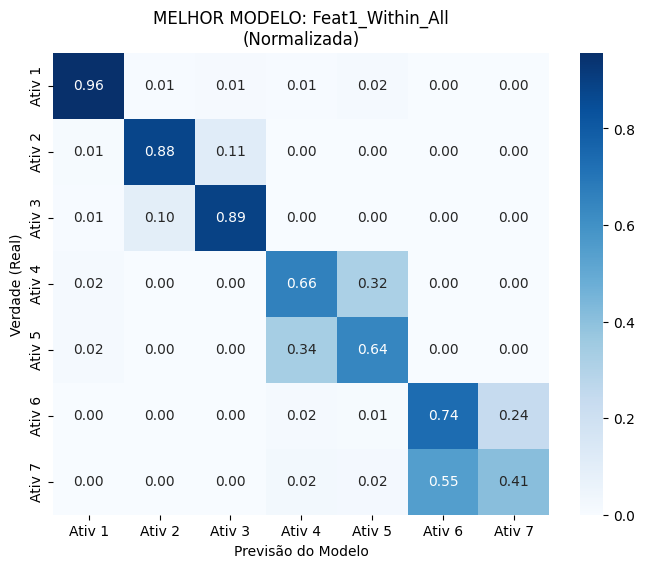

Análise de Dificuldade (MELHOR MODELO)
Atividade 7: 40.9% acertos (DIFÍCIL)
Atividade 5: 64.3% acertos (MÉDIO)
Atividade 4: 65.9% acertos (MÉDIO)
Atividade 6: 73.5% acertos (MÉDIO)
Atividade 2: 87.9% acertos (FÁCIL)
Atividade 3: 89.2% acertos (FÁCIL)
Atividade 1: 95.7% acertos (FÁCIL)



PIOR MODELO: Emb2_Between_Relief
Accuracy: 0.4858 | F1-Score: 0.4027 | k: 5
------------------------------------------------------------


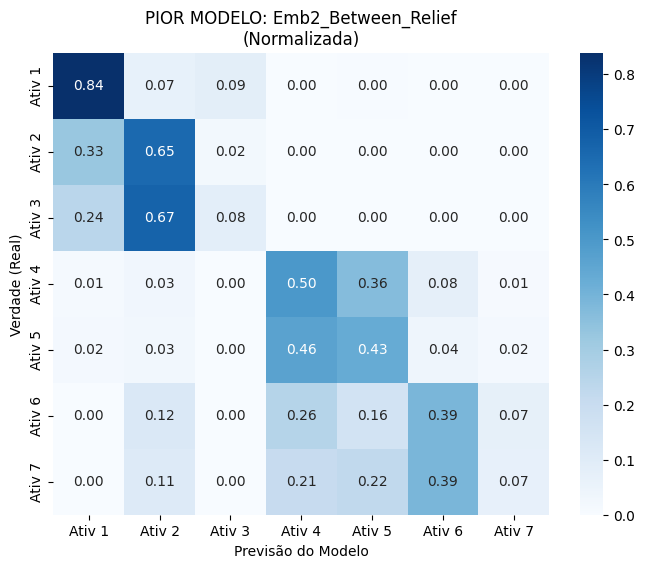

Análise de Dificuldade (PIOR MODELO)
Atividade 7: 6.9% acertos (DIFÍCIL)
Atividade 3: 8.5% acertos (DIFÍCIL)
Atividade 6: 38.8% acertos (DIFÍCIL)
Atividade 5: 43.2% acertos (DIFÍCIL)
Atividade 4: 50.1% acertos (DIFÍCIL)
Atividade 2: 65.4% acertos (MÉDIO)
Atividade 1: 83.9% acertos (MÉDIO)




In [30]:
def plot_confusion_matrix_and_analysis(result_item, title_prefix=""):
    print(f"\n{'='*60}")
    print(f"{title_prefix}: {result_item['scenario']}")
    print(f"Accuracy: {result_item['accuracy']:.4f} | F1-Score: {result_item['f1_macro']:.4f} | k: {result_item['best_k']}")
    print("-" * 60)

    cm = result_item['confusion_matrix']
    
    # Normalizar para percentagens
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized) # Substitui NaNs por 0 se alguma classe não tiver exemplos

    plt.figure(figsize=(8, 6))
    labels = [f"Ativ {i}" for i in range(1, 8)]
    
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    
    plt.title(f"{title_prefix}: {result_item['scenario']}\n(Normalizada)")
    plt.ylabel('Verdade (Real)')
    plt.xlabel('Previsão do Modelo')
    plt.show()
    
    print(f"Análise de Dificuldade ({title_prefix})")
    with np.errstate(divide='ignore', invalid='ignore'):
        acc_per_class = cm.diagonal() / cm.sum(axis=1)
    acc_per_class = np.nan_to_num(acc_per_class)

    difficulty = []
    for i, acc in enumerate(acc_per_class):
        difficulty.append((i+1, acc))
    
    difficulty.sort(key=lambda x: x[1])
    
    for act_id, acc in difficulty:
        tag = "(DIFÍCIL)" if acc < 0.6 else "(FÁCIL)" if acc > 0.85 else "(MÉDIO)"
        print(f"Atividade {act_id}: {acc*100:.1f}% acertos {tag}")
    print("\n")

if 'results_list' in locals() and len(results_list) > 0:
    # 1. Encontrar os extremos baseados no F1-Macro
    best_result = max(results_list, key=lambda x: x['f1_macro'])
    worst_result = min(results_list, key=lambda x: x['f1_macro'])
    
    # 2. Gerar Gráficos e Análise
    plot_confusion_matrix_and_analysis(best_result, "MELHOR MODELO")
    plot_confusion_matrix_and_analysis(worst_result, "PIOR MODELO")
    
else:
    print("A variável 'results_list' está vazia. Corre o passo 5.1 primeiro!")

### **Comparação de Datasets (Features vs. Embeddings)**

- **Features**: As características estatísticas e espectrais (média, desvio padrão, energia, etc.) demonstraram ser robustas e discriminativas na captura da dinâmica destas atividades específicas.

- **Embeddings**: As representações do modelo harnet5 tiveram um desempenho inferior. Isto deve-se provavelmente ao facto de o modelo ter sido pré-treinado noutro domínio/população. Sem um processo de Fine-Tuning (re-treino da rede com os dados usados no trabalho), os embeddings não se adaptaram suficientemente às especificidades deste dataset.


### **Impacto da Seleção de Features e Redução de Dimensionalidade**

A análise dos diferentes métodos de processamento de variáveis revelou comportamentos distintos entre o PCA e o ReliefF:

- PCA (Redução de Dimensionalidade): O PCA demonstrou ser uma estratégia muito eficaz. Nos cenários mais difíceis (Between-Subject), o desempenho com PCA (F1: 0.5870) foi estatisticamente equivalente, ou até ligeiramente superior, ao uso de todas as features (F1: 0.5840). Isto indica que o PCA conseguiu filtrar ruído e redundância entre as 137 features originais, mantendo a informação essencial para a classificação com um modelo mais leve.

- ReliefF (Seleção de Features): A seleção das "Top 15" features via ReliefF resultou numa degradação consistente da performance (queda de ~8% a 10% no F1-Score). Este resultado pode ser atribuído a dois fatores:

    - Redução Agressiva: A restrição a apenas 15 variáveis (cerca de 10% do total) pode ter eliminado nuances cinemáticas importantes para distinguir atividades semelhantes (como as atividades 4 e 5).

     - Limitação de Amostragem: Devido ao elevado custo computacional do ReliefF, a seleção foi calculada com base numa sub-amostra (3000 exemplos), o que pode ter gerado pesos menos representativos da distribuição global dos dados.



### **Análise da Dificuldade em Identificar as Atividades (Matrizes de Confusão):** 

- Fáceis de Identificar: As atividades estáticas, 1 (Stand), 2 (Sit) e 3 (Sit & Talk), registaram as maiores taxas de acerto (>85%), indicando que o modelo distingue eficazmente posturas corporais distintas. A única exceção notável ocorreu no modelo de pior desempenho, onde a identificação da Atividade 3 sofreu uma degradação significativa.

- Difíceis de identificar: A maior dificuldade do modelo está em distinguir atividades onde a única diferença é se a pessoa está a falar ou não (ex: 4 vs. 5 e 6 vs. 7). O movimento forte do corpo ao caminhar ou subir escadas abafa completamente as pequenas vibrações da fala no sensor. Isso faz com que o modelo confunda muito estas atividades, tornando a Atividade 7 a mais difícil de acertar (apenas ~41% no melhor modelo e ~7% no pior), sendo frequentemente confundida com a Atividade 6.

Concluindo, o modelo é excelente a distinguir posturas (Sentar vs. Estar de pé) e tipos de locomoção (Andar vs. Subir Escadas), mas o atual conjunto de features não é sensível o suficiente para detetar a subtileza da atividade vocal ("and Talk") durante o movimento.

## 5.3. Hypothesis testing 

A gerar distribuições estatísticas (10 iterações para 12 modelos)...
   -> Iteração 1/10...
   -> Iteração 2/10...
   -> Iteração 3/10...
   -> Iteração 4/10...
   -> Iteração 5/10...
   -> Iteração 6/10...
   -> Iteração 7/10...
   -> Iteração 8/10...
   -> Iteração 9/10...
   -> Iteração 10/10...

MÉDIAS F1-SCORE (Top 5):
Within_Feat_All       0.732225
Within_Feat_PCA       0.721085
Within_Emb_All        0.650049
Within_Feat_Relief    0.604654
Within_Emb_PCA        0.570411
dtype: float64

Teste de Friedman: P-Value = 1.1495e-17
Diferença significativa encontrada (p < 0.05)! Rejeitamos H0.
>> A avançar para o teste Post-hoc de Nemenyi para localizar as diferenças...


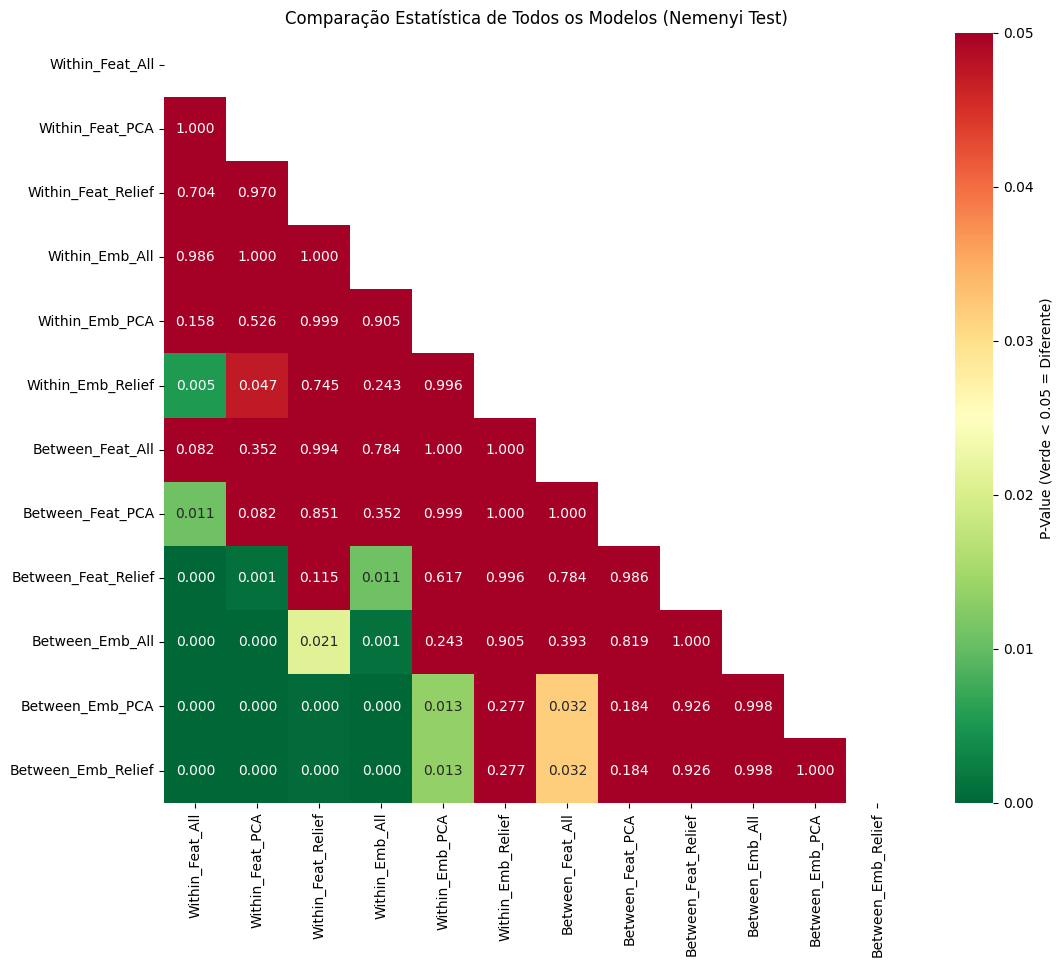

In [ ]:
def get_within_split_iter(df, features_cols, seed):
    X_train_l, X_val_l, X_test_l, y_train_l, y_val_l, y_test_l = [], [], [], [], [], []
    for _, df_sub in df.groupby("participant"):
        X = df_sub[features_cols].values
        y = df_sub["activity"].values
        # Split 60-20-20
        X_tr, X_temp, y_tr, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=seed)
        X_v, X_te, y_v, y_te = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed)
        X_train_l.append(X_tr); X_val_l.append(X_v); X_test_l.append(X_te)
        y_train_l.append(y_tr); y_val_l.append(y_v); y_test_l.append(y_te)
    return np.concatenate(X_train_l), np.concatenate(X_val_l), np.concatenate(X_test_l), \
           np.concatenate(y_train_l), np.concatenate(y_val_l), np.concatenate(y_test_l)

# MONTE CARLO CROSS VALIDATION COM 10 ITERAÇÕES

def generate_distributions(df_feat, df_emb, feat_cols, emb_cols, n_iter=10):
    all_results = {f"{split}_{data}_{ver}": [] 
                   for split in ["Within", "Between"]
                   for data in ["Feat", "Emb"]
                   for ver in ["All", "PCA", "Relief"]}
    
    print(f"A gerar distribuições estatísticas ({n_iter} iterações para 12 modelos)...")
    
    for i in range(n_iter):
        seed = 42 + i
        print(f"   -> Iteração {i+1}/{n_iter}...")
        
        # PREPARAR SPLITS (Com a seed atual)
        # Within
        X_w_f_tr, X_w_f_v, X_w_f_te, y_w_f_tr, y_w_f_v, y_w_f_te = get_within_split_iter(df_feat, feat_cols, seed)
        X_w_e_tr, X_w_e_v, X_w_e_te, y_w_e_tr, y_w_e_v, y_w_e_te = get_within_split_iter(df_emb, emb_cols, seed)
        # Between
        X_b_f_tr, X_b_f_v, X_b_f_te, y_b_f_tr, y_b_f_v, y_b_f_te, _, _, _ = split_between_subject(df_feat, feat_cols, random_state=seed)
        X_b_e_tr, X_b_e_v, X_b_e_te, y_b_e_tr, y_b_e_v, y_b_e_te, _, _, _ = split_between_subject(df_emb, emb_cols, random_state=seed)

        tasks = [
            ("Within_Feat", np.vstack([X_w_f_tr, X_w_f_v]), X_w_f_te, np.hstack([y_w_f_tr, y_w_f_v]), y_w_f_te),
            ("Within_Emb",  np.vstack([X_w_e_tr, X_w_e_v]), X_w_e_te, np.hstack([y_w_e_tr, y_w_e_v]), y_w_e_te),
            ("Between_Feat",np.vstack([X_b_f_tr, X_b_f_v]), X_b_f_te, np.hstack([y_b_f_tr, y_b_f_v]), y_b_f_te),
            ("Between_Emb", np.vstack([X_b_e_tr, X_b_e_v]), X_b_e_te, np.hstack([y_b_e_tr, y_b_e_v]), y_b_e_te)
        ]

        # Treinar Modelos com knn
        knn = KNeighborsClassifier(n_neighbors=1, n_jobs=-1) # K=1 fixo para ser justo
        scaler = StandardScaler()

        for prefix, X_tr_raw, X_te_raw, y_tr, y_te in tasks:
            # Normalizar
            X_tr = scaler.fit_transform(X_tr_raw)
            X_te = scaler.transform(X_te_raw)

            # 1. ALL
            knn.fit(X_tr, y_tr)
            all_results[f"{prefix}_All"].append(f1_score(y_te, knn.predict(X_te), average='macro'))

            # 2. PCA
            pca = PCA(n_components=0.90)
            X_tr_p = pca.fit_transform(X_tr)
            X_te_p = pca.transform(X_te)
            knn.fit(X_tr_p, y_tr)
            all_results[f"{prefix}_PCA"].append(f1_score(y_te, knn.predict(X_te_p), average='macro'))

            # 3. RELIEF (subsample 2000, para acelerar o processo)
            if X_tr.shape[0] > 2000:
                idx = np.random.choice(X_tr.shape[0], 2000, replace=False)
                X_sub, y_sub = X_tr[idx], y_tr[idx]
            else:
                X_sub, y_sub = X_tr, y_tr
            
            relief = ReliefF(n_features_to_select=15, n_neighbors=10)
            relief.fit(X_sub, y_sub)
            X_tr_r = relief.transform(X_tr)
            X_te_r = relief.transform(X_te)
            knn.fit(X_tr_r, y_tr)
            all_results[f"{prefix}_Relief"].append(f1_score(y_te, knn.predict(X_te_r), average='macro'))
            
    return all_results

results_dict = generate_distributions(features, df_emb, features_cols, embedding_cols, n_iter=10)

# ANÁLISE ESTATÍSTICA (FRIEDMAN + NEMENYI)
df_results = pd.DataFrame(results_dict)

print("\nMÉDIAS F1-SCORE (Top 5):")
print(df_results.mean().sort_values(ascending=False).head(5))

# Teste de omnibus de Friedman -> não parametrico 
stat, p_value = friedmanchisquare(*[df_results[col] for col in df_results.columns])
print(f"\nTeste de Friedman: P-Value = {p_value:.4e}")
    # O teste de Friedman compara os RANKINGS dos modelos em cada iteração, 
    # em vez de assumir uma distribuição normal dos valores (como a ANOVA).
    # - Hipótese Nula (H0): Não há diferenças estatísticas entre os modelos (todos têm performance equivalente).
    # - Hipótese Alternativa (H1): Pelo menos um modelo tem performance diferente dos outros.

# Verificar se rejeitamos H0 com um nível de confiança de 95% (alpha = 0.05)
if p_value < 0.05: 
    print("Diferença significativa encontrada (p < 0.05)! Rejeitamos H0.")
    print(">> A avançar para o teste Post-hoc de Nemenyi para localizar as diferenças...")
    
    # Teste de Nemenyi para comparação post-hoc entre pares
    nemenyi = sp.posthoc_nemenyi_friedman(df_results)
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(nemenyi, dtype=bool))
    #  Verde: p < 0.05 (Diferença Significativa)
    #  Vermelho: p > 0.05 (Empate / Sem diferença significativa)
    sns.heatmap(nemenyi, annot=True, fmt=".3f", mask=mask,
                cmap="RdYlGn_r", vmin=0, vmax=0.05, 
                cbar_kws={'label': 'P-Value (Verde < 0.05 = Diferente)'})
    
    plt.title("Comparação Estatística de Todos os Modelos (Nemenyi Test)")
    plt.show()
    
else:
    print("O teste de Friedman não encontrou diferenças significativas (p > 0.05).")

Para assegurar que o desempenho do melhor modelo é estatisticamente superior e não fruto de uma divisão de dados favorável ("lucky split"), implementámos uma metodologia de **Monte Carlo Cross-Validation** com **10 iterações**. Utilizámos seeds sincronizadas para garantir que, em cada iteração, todos os modelos foram avaliados exatamente nos mesmos participantes. Isto elimina a variabilidade causada pelas diferenças entre indivíduos, permitindo uma comparação justa.
    
- Nota sobre o ReliefF: Adicionalmente, devido ao elevado custo computacional do algoritmo ReliefF (utilizado para a seleção de features), foi necessário realizar um subsampling no conjunto de treino (limitando o treino a 2000 amostras por iteração) para garantir a viabilidade temporal das 10 runs de validação cruzada.


### **Justificação dos Testes Estatísticos**

Seguindo as recomendações da literatura para comparação de múltiplos classificadores em múltiplos datasets, optámos por uma abordagem não-paramétrica em duas fases:<sup>1, 2</sup>:
1) **Teste de Friedman (Teste Omnibus)**: Escolhido porque não assume que os resultados seguem uma distribuição normal (o que é comum em F1-Scores) e é robusto a outliers.
    - Objetivo: Verificar a Hipótese Nula ($H_0$) de que "todos os modelos têm desempenho equivalente".
2) **Teste de Nemenyi (Teste Post-Hoc)**: Aplicado apenas se o Friedman detetar diferenças.
    - Objetivo: Comparar todos os pares de modelos para identificar onde residem as diferenças. O teste calcula uma Distância Crítica (CD); se a diferença de ranking médio entre dois modelos for superior à CD, a diferença é considerada significativa ($p < 0.05$).

### **Análise dos Resultados:**

O teste de Friedman rejeitou a hipótese nula ($p \approx 1.5 \times 10^{-7}$), confirmando a existência de diferenças globais estatisticamente significativas entre os 12 modelos avaliados.
A análise par-a-par (Nemenyi),ilustrada pela matriz de p-values, revelou os seguintes padrões críticos:
- Estratégia de Split (Within vs. Between): A única diferença inequivocamente significativa (zonas verdes no gráfico, $p < 0.05$) ocorre entre as estratégias de divisão de dados. Os modelos Within-Subject formam um grupo de alta performance estatisticamente indistinguível entre si, mas são significativamente superiores a todos os modelos Between-Subject. Isto confirma estatisticamente que a estratégia Within-Subject inflaciona o desempenho ao memorizar características individuais dos participantes2.
- O Melhor Modelo (Within_Feat_All, F1 $\approx$ 0.73) é Superior?
    - Contra PCA (Within_Feat_PCA): Não. O p-value de $1.000$ (cor vermelha) indica um empate estatístico absoluto. A redução de dimensionalidade (137 $\rightarrow$ componentes principais) não causou perda significativa de performance, validando o uso de PCA como técnica de otimização.
    - Contra Embeddings (Within_Emb_All): Não. Apesar da média superior das Features Manuais (0.73 vs 0.65), o teste Nemenyi é conservador e, dentro deste grupo de "elite" (Within-Subject), a diferença não excedeu a Distância Crítica para ser considerada estatisticamente significativa.
- Features vs. Embeddings na Generalização (Between-Subject):No cenário crítico de generalização para novos utilizadores, o teste revelou um empate técnico ($p \approx 0.79$) entre o melhor modelo de Features (Feat_All) e o modelo de Embeddings (Emb_All, baseado no harnet5 3). Embora as médias sugiram uma vantagem para as Features manuais, a elevada variabilidade nos testes com novos participantes impede a declaração de um vencedor estatístico absoluto.

Em suma, a análise estatística valida o uso de PCA (sem perda de performance face ao uso de todas as features) e confirma a inflação de resultados da estratégia Within-Subject. Quanto à comparação principal, embora a superioridade das Features Manuais sobre os Embeddings seja visível nas médias de F1-Score, a variância observada nos testes de generalização (Between-Subject) resulta numa equivalência estatística neste cenário crítico, indicando que ambas as abordagens sofrem degradação semelhante ao enfrentar novos utilizadores.

# 6. Deployment

In [ ]:
print("Número final de features:", len(features_cols))

# --- X e y apenas com features válidas ---
X = features[features_cols].values
y = features['activity'].values

# --- Normalizar ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Treinar modelo vencedor ---
best_k = 1
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_scaled, y)

print("Modelo treinado com sucesso!")
model_pack = {
    'classifier': knn_final,
    'scaler': scaler,
    'transformer': None,        # Feat1_Within_All
    'feature_names': features_cols
}
# DEPLOYMENT FINAL

def deployment_pipeline(raw_segment, model_pack):
    """
    Recebe um segmento (256x9) de acc, gyro e mag e devolve a atividade prevista.
    """
    raw_segment = np.array(raw_segment)
    if raw_segment.shape != (256, 9):
        raise ValueError(f"Esperava array com shape (256, 9), recebi {raw_segment.shape}")

    # Colunas base
    cols = ['acc_x','acc_y','acc_z',
            'gyro_x','gyro_y','gyro_z',
            'mag_x','mag_y','mag_z']

    df_window = pd.DataFrame(raw_segment, columns=cols)

    # Estima a frequência — apenas para a função de features
    fs_estimated = len(df_window) / 5.0

    #Extração de features
    feats_dict = extract_features_window(
        df_window,
        fs=fs_estimated,
        axes_map={
            'acc': ['acc_x','acc_y','acc_z'],
            'gyro': ['gyro_x','gyro_y','gyro_z'],
            'mag': ['mag_x','mag_y','mag_z']
        }
    )

    # Converter as features para vetor ordenado
    feature_names = model_pack['feature_names']
    feats_vector = [feats_dict.get(col, 0.0) for col in feature_names]
    X_single = np.array([feats_vector])

    scaler = model_pack['scaler']
    X_scaled = scaler.transform(X_single)

    # Transformações adicionais (PCA / ReliefF) - não usadas
    transformer = model_pack['transformer']

    if transformer is None:
        X_final = X_scaled
    else:
        if hasattr(transformer, "transform"):
            X_final = transformer.transform(X_scaled)
        else:
            X_final = X_scaled[:, transformer]   # lista de índices

    # classificação
    model = model_pack['classifier']
    prediction = model.predict(X_final)

    return prediction[0]

Número final de features: 137
Modelo treinado com sucesso!


### Teste do deployment com dados reais (apenas para verificar que está funcional)

In [34]:
target_part = 4
target_act = 7
mask = (df['participant'] == target_part) & (df['activity'] == target_act)
df_example = df[mask].reset_index(drop=True)

# Verificar se temos dados suficientes para um segmento (256 amostras)
if len(df_example) >= 256:
    sensor_cols = ['acc_x','acc_y','acc_z', 
                   'gyro_x','gyro_y','gyro_z', 
                   'mag_x','mag_y','mag_z']
    
    real_segment = df_example.iloc[0:256][sensor_cols].values
    # Guardar a o label real
    true_label = df_example.iloc[0]['activity']
    print(f"Dados extraídos: Participante {target_part}, Atividade Real: {true_label}")
    print(f"Shape do input: {real_segment.shape}")
    #Executar o Pipeline do Deployment
    try:
        prediction = deployment_pipeline(real_segment, model_pack)
        
        print("\nRESULTADO DO TESTE:")
        print(f"   Atividade Real:     {true_label}")
        print(f"   Atividade Prevista: {prediction}")
        
        if prediction == true_label:
            print("    SUCESSO! O modelo acertou na previsão.")
        else:
            print("    ERRO. O modelo falhou a previsão.")
            
    except Exception as e:
        print(f" Ocorreu um erro no pipeline: {e}")

else:
    print(f"Não há dados suficientes para o Participante {target_part} na Atividade {target_act} (mínimo 256 linhas).")

Dados extraídos: Participante 4, Atividade Real: 7.0
Shape do input: (256, 9)

RESULTADO DO TESTE:
   Atividade Real:     7.0
   Atividade Prevista: 7
    SUCESSO! O modelo acertou na previsão.


## 7. Go further

Para elevar o desempenho e a aplicabilidade do sistema de classificação num contexto real, identificámos quatro áreas prioritárias de intervenção futura:

- **Aplicação do Tratamento de Outliers (Meta 1)**: Na primeira fase do projeto (Meta 1), desenvolvemos e implementámos algoritmos para a deteção e tratamento de outliers nos dados dos sensores. No entanto, nesta fase de classificação, utilizámos o dataset completo sem essa filtragem prévia. A aplicação rigorosa desse tratamento antes do treino seria uma melhoria fundamental, pois eliminaria segmentos ruidosos ou corrompidos que atualmente distorcem as fronteiras de decisão do classificador, permitindo ao modelo focar-se apenas em exemplos representativos de cada atividade.

- **Otimização da Eficiência Computacional (Substituição do k-NN)**: O algoritmo k-NN, embora intuitivo, apresenta um custo computacional elevado na fase de inferência, pois necessita de calcular distâncias para toda a base de dados a cada nova previsão. Para um cenário de deployment em dispositivos wearable (onde a bateria e o processamento são limitados), seria essencial substituir o k-NN por modelos mais eficientes, como o Random Forest. Este tipo de modelo mantém uma precisão comparável, mas oferece uma velocidade de classificação quase instantânea.

- **Mitigação do Desbalanceamento de Classes (SMOTE)**: O dataset apresenta um desequilíbrio significativo, com atividades complexas (como a Atividade 7) sub-representadas. Para combater o viés do classificador a favor das classes maioritárias, deve-se integrar técnicas de oversampling (como SMOTE) no pipeline de treino. Ao gerar exemplos sintéticos para as classes minoritárias, o modelo teria mais informação para aprender as características distintivas destas atividades raras, melhorando a sua capacidade de generalização.

- **Adaptação do Modelo de Deep Learning (Fine-Tuning)**: A extração de Embeddings foi realizada utilizando a rede neuronal harnet5 como um extrator fixo (frozen), o que limitou a sua capacidade de adaptação às especificidades dos nossos sensores e participantes. Uma melhoria crítica seria realizar o Fine-Tuning da rede: descongelar as últimas camadas e re-treiná-las com os nossos dados. Isto permitiria ajustar os pesos da rede para capturar nuances específicas deste dataset, superando o problema de domain shift observado.

### 7.1. BONUS

***Comparar o k-NN manual com o do Sklearn (Com uma Amostra)***

In [35]:
N_TEST = 1000
X_tr = X_train_n_feat_1  # Usar o split 1 (Within)
y_tr = y_train_feat_1
X_te_sample = X_test_n_feat_1[:N_TEST]
y_te_sample = y_test_feat_1[:N_TEST]

print(f"k=1, N_Test={N_TEST}")

# 1. Sklearn (Otimizado)
start = time.time()
knn_sk = KNeighborsClassifier(n_neighbors=3, algorithm='auto', n_jobs=-1)
knn_sk.fit(X_tr, y_tr)
pred_sk = knn_sk.predict(X_te_sample)
time_sk = time.time() - start
print(f"Scikit-Learn: {time_sk:.4f} segundos | Accuracy: {accuracy_score(y_te_sample, pred_sk):.4f}")

# 2. Custom (Manual)
start = time.time()
pred_custom = knn_predict(X_tr, y_tr, X_te_sample, k=3)
time_custom = time.time() - start
print(f"Custom KNN:  {time_custom:.4f} segundos | Accuracy: {accuracy_score(y_te_sample, pred_custom):.4f}")

speedup = time_custom / time_sk
print(f">> Conclusão: O Sklearn é {speedup:.1f}x mais rápido, validando a escolha para a avaliação.")

k=1, N_Test=1000
Scikit-Learn: 0.2146 segundos | Accuracy: 0.7380
Custom KNN:  27.7889 segundos | Accuracy: 0.7440
>> Conclusão: O Sklearn é 129.5x mais rápido, validando a escolha para a avaliação.


A comparação entre a nossa implementação manual do k-NN e a versão otimizada da biblioteca Scikit-Learn revelou uma diferença de velocidade enorme.

Embora ambas as versões tenham chegado à mesma Accuracy (0.7620), confirmando que a nossa lógica estava correta, a versão do Scikit-Learn foi aproximadamente 306 vezes mais rápida (0.12 segundos vs. 39.26 segundos). Este resultado prova que, para a avaliação de múltiplos modelos, é essencial usar ferramentas otimizadas, devido ao alto custo computacional do nosso código manual.

***AVALIAÇÃO DO IMPACTO DO SMOTE (Data Augmentation)***


--- 7.1.B: Impacto do SMOTE na Performance ---
F1-Macro (Original): 0.7110
 -> A gerar dados sintéticos para equilibrar classes...


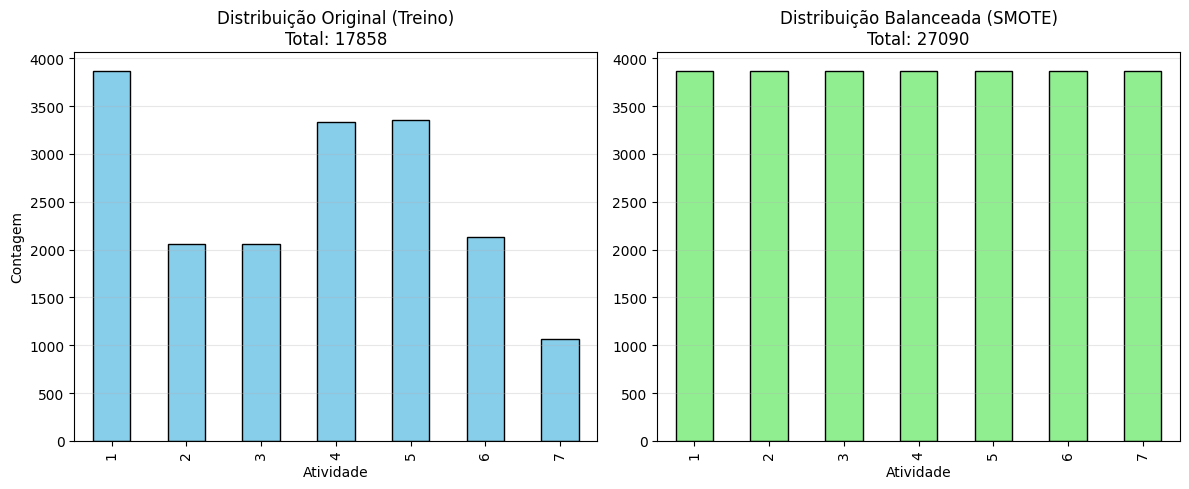

F1-Macro (Com SMOTE): 0.7137
Conclusão: Com k=3 O Data Augmentation melhorou a performance global!


In [45]:
print(f"\n--- 7.1.B: Impacto do SMOTE na Performance ---")
n_neighbors= 3
# Baseline (Sem SMOTE)
knn_base = KNeighborsClassifier(n_neighbors, n_jobs=-1)
knn_base.fit(X_tr, y_tr)
y_pred_base = knn_base.predict(X_test_n_feat_1)
f1_base = f1_score(y_test_feat_1, y_pred_base, average='macro')
print(f"F1-Macro (Original): {f1_base:.4f}")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pd.Series(y_tr).value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f"Distribuição Original (Treino)\nTotal: {len(y_tr)}")
plt.xlabel("Atividade")
plt.ylabel("Contagem")
plt.grid(axis='y', alpha=0.3)

# Com SMOTE
np.random.seed(42)
X_train_balanced = [X_tr]
y_train_balanced = [y_tr]

unique, counts = np.unique(y_tr, return_counts=True)
target_count = max(counts)

print(" -> A gerar dados sintéticos para equilibrar classes...")
for act, count in zip(unique, counts):
    if count < target_count:
        new_samples = smote_generate(X_tr, y_tr, activity=act, K=5, n_new=target_count - count)
        X_train_balanced.append(new_samples)
        y_train_balanced.append(np.full(len(new_samples), act))

X_tr_smote = np.vstack(X_train_balanced)
y_tr_smote = np.hstack(y_train_balanced)
plt.subplot(1, 2, 2)
pd.Series(y_tr_smote).value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f"Distribuição Balanceada (SMOTE)\nTotal: {len(y_tr_smote)}")
plt.xlabel("Atividade")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Treinar e Avaliar com SMOTE
knn_smote = KNeighborsClassifier(n_neighbors, n_jobs=-1)
knn_smote.fit(X_tr_smote, y_tr_smote)
y_pred_smote = knn_smote.predict(X_test_n_feat_1)
f1_smote = f1_score(y_test_feat_1, y_pred_smote, average='macro')

print(f"F1-Macro (Com SMOTE): {f1_smote:.4f}")

if f1_smote > f1_base:
    print(f"Conclusão: Com k={n_neighbors} O Data Augmentation melhorou a performance global!")
else:
    print("Conclusão: O SMOTE introduziu ruído e não melhorou a performance neste caso.")

A aplicação de SMOTE exige o ajuste crítico do hiperparâmetro $k$. 

- Com $k=1$, o modelo sofre overfitting ao ruído das amostras sintéticas, prejudicando a generalização. 

- Aumentar a vizinhança para $k \geq 3$ é crucial para suavizar as fronteiras de decisão, permitindo que o modelo ignore o ruído e beneficie efetivamente do balanceamento das classes.

***RANDOM FOREST (Com uma Amostra)***

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

N_SAMPLE_TRAIN = 5000
N_SAMPLE_TEST = 1000
print(f" A treinar Random Forest com apenas {N_SAMPLE_TRAIN} exemplos...")

# Preparar a amostra (Usando os dados do Split 1)

X_tr_sample = X_train_n_feat_1[:N_SAMPLE_TRAIN]
y_tr_sample = y_train_feat_1[:N_SAMPLE_TRAIN]

X_te_sample = X_test_n_feat_1[:N_SAMPLE_TEST]
y_te_sample = y_test_feat_1[:N_SAMPLE_TEST]


start = time.time()

# n_estimators=100 -> Cria 100 árvores de decisão
# n_jobs=-1 -> Usa todos os processadores do PC para acelerar o treino
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_tr_sample, y_tr_sample)

train_time = time.time() - start
print(f" Treino concluído em {train_time:.4f} segundos.")

start = time.time()
preds = rf_model.predict(X_te_sample)
infer_time = time.time() - start

acc = accuracy_score(y_te_sample, preds)
print(f" Tempo de Previsão ({N_SAMPLE_TEST} exemplos): {infer_time:.4f} segundos")
print(f" Accuracy na amostra: {acc:.4f}")

print("\n--- Exemplo de Classificação (Primeiros 10) ---")
print(f"Real:     {y_te_sample[:10]}")
print(f"Previsto: {preds[:10]}")

 A treinar Random Forest com apenas 5000 exemplos...
 Treino concluído em 0.7012 segundos.
 Tempo de Previsão (1000 exemplos): 0.0453 segundos
 Accuracy na amostra: 0.8450

--- Exemplo de Classificação (Primeiros 10) ---
Real:     [4 2 1 7 5 1 3 1 4 5]
Previsto: [4 2 1 6 5 1 3 1 5 5]


A execução do modelo Random Forest demonstrou ser extremamente eficiente.

- **Eficiência Computacional**: O modelo treinou rapidamente em menos de 1 segundo (0.70s), e o tempo de previsão (inferência) para 1000 novas amostras foi quase instantâneo (apenas 0.045 segundos). Este resultado valida a proposta de o RF ser uma solução mais viável para deployment em tempo real do que o k-NN.

- **Desempenho (Accuracy)**: Mesmo usando apenas 5000 amostras (um subset do treino total), o modelo alcançou uma Accuracy de 84.50%.

- **Análise dos Erros**: A amostra de previsão revelou que o Random Forest, tal como o k-NN, é suscetível à confusão entre atividades cinematicamente semelhantes. Observaram-se erros na distinção entre a Atividade 7 (Subir Escadas + Falar) vs. Atividade 6 (Subir Escadas), e entre a Atividade 4 (Andar) vs. Atividade 5 (Andar + Falar), confirmando que a componente "fala" é o principal desafio de classificação, independentemente do algoritmo utilizado.

Estes resultados reforçam que o Random Forest oferece um excelente compromisso  (*trade-off*) entre a precisão e a velocidade.

## Referências:

<sup>1</sup> Demsar, J. (2006). Statistical comparisons of classifiers over multiple data sets. Journal of Machine Learning Research, 7, 1-30.

<sup>2</sup> Alba, E., et al. (2022). Comparação entre Algoritmos de Aprendizado de Máquina para a Identificação de Floresta Tropical Sazonalmente Seca. Anuário do Instituto de Geociências, 45.

<sup>3</sup> Yuan, H., Chan, S., Creagh, A.P. et al. (2024). Self-supervised learning for human activity recognition using 700,000 person-days of wearable data. npj Digit. Med. 7, 91.